/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

SEQ_LEN=13  X=(600, 13)  VOCAB=32,000
[PE 없음]
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - loss: 10.3163
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.0432
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7109
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.3343
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9219
[PE 있음]
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - loss: 10.3133
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.0150
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6828
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.3169
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.9206


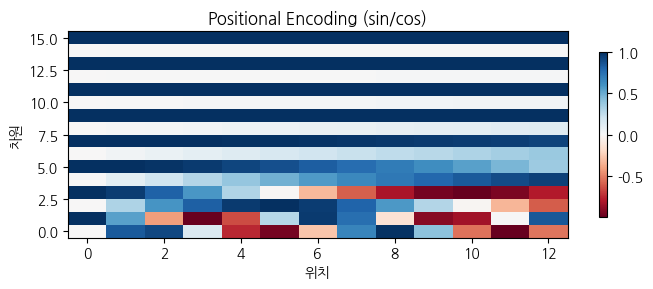

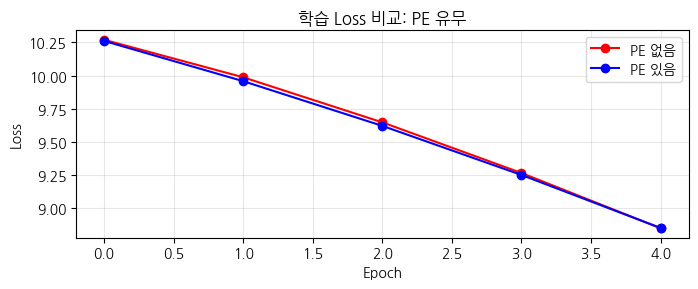

최종 Loss  PE 없음: 8.8439
최종 Loss  PE 있음: 8.8460


In [2]:
# 실습 7 · Positional Encoding 유무 비교
import sys

if "google.colab" in sys.modules:
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib", "transformers"], check=True)

import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import koreanize_matplotlib

SEED = 42;  np.random.seed(SEED);  tf.random.set_seed(SEED)

# ---- 설정 ----
D_MODEL = 16
N_HEADS = 1
EPOCHS  = 5
BATCH   = 64

# ---- 실험 권장 (1~2개만 수정) ----
# D_MODEL = 32   # 차원 증가    -> Loss 감소 폭 비교
# N_HEADS = 2    # 헤드 수 증가 -> PE 효과가 더 뚜렷해지는가?
# EPOCHS  = 10   # 에폭 증가    -> 두 모델 수렴 차이 관찰
# BATCH   = 128  # 배치 증가    -> 학습 속도 변화 확인


# --- Positional Encoding ---
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos    = np.arange(seq_len)[:, np.newaxis]
        dims   = np.arange(d_model)[np.newaxis, :]
        angles = pos / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.cast(angles[np.newaxis], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]


# --- 데이터 ---
sentences = [
    "고양이가 매트 위에 앉았다 그것이 부드러워서",
    "고양이가 매트 위에 앉았다 그것이 피곤해서",
    "강아지가 공원으로 달려갔다 그것이 넓어서",
    "강아지가 공원으로 달려갔다 그것이 신나서",
    "새가 나무로 날아갔다 그것이 높아서",
    "새가 나무로 날아갔다 그것이 배고파서",
] * 100

tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
SEQ_LEN   = max(len(tokenizer.tokenize(s)) for s in sentences[:6]) + 1
VOCAB     = tokenizer.vocab_size
pad_id    = tokenizer.pad_token_id

def encode_m2m(sents):
    X, Y = [], []
    for s in sents:
        ids = tokenizer.encode(s, add_special_tokens=False)
        ids = (ids + [pad_id] * (SEQ_LEN + 1))[:SEQ_LEN + 1]
        X.append(ids[:-1]);  Y.append(ids[1:])
    return np.array(X, dtype=np.int32), np.array(Y, dtype=np.int32)

X, y  = encode_m2m(sentences)
dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(BATCH)
print(f"SEQ_LEN={SEQ_LEN}  X={X.shape}  VOCAB={VOCAB:,}")


# --- 모델 ---
def build_model(use_pe):
    inp = layers.Input(shape=(SEQ_LEN,))
    x   = layers.Embedding(VOCAB, D_MODEL)(inp)
    if use_pe:
        x = PositionalEncoding(SEQ_LEN, D_MODEL)(x)
    attn_out, _ = layers.MultiHeadAttention(
                      num_heads=N_HEADS, key_dim=D_MODEL)(
                      x, x, x, return_attention_scores=True)
    x   = layers.LayerNormalization()(x + attn_out)
    out = layers.Dense(VOCAB)(x)
    m   = keras.Model(inp, out)
    m.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer="adam")
    return m

model_no = build_model(use_pe=False)
model_pe = build_model(use_pe=True)


# --- 학습 ---
print("[PE 없음]")
h1 = model_no.fit(dataset, epochs=EPOCHS, verbose=1)

print("[PE 있음]")
h2 = model_pe.fit(dataset, epochs=EPOCHS, verbose=1)


# --- 시각화 1 : PE 패턴 ---
pe_vals = PositionalEncoding(SEQ_LEN, D_MODEL).pe.numpy()[0]
fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(pe_vals.T, aspect="auto", cmap="RdBu", origin="lower")
ax.set(xlabel="위치", ylabel="차원", title="Positional Encoding (sin/cos)")
plt.colorbar(im, ax=ax, shrink=0.8);  plt.tight_layout()
plt.savefig("fig07_pe_pattern.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 시각화 2 : Loss 비교 ---
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(h1.history["loss"], "r-o", label="PE 없음")
ax.plot(h2.history["loss"], "b-o", label="PE 있음")
ax.set(xlabel="Epoch", ylabel="Loss", title="학습 Loss 비교: PE 유무")
ax.legend();  ax.grid(True, alpha=0.3);  plt.tight_layout()
plt.savefig("fig07_pe_loss.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 결과 ---
print(f"최종 Loss  PE 없음: {h1.history['loss'][-1]:.4f}")
print(f"최종 Loss  PE 있음: {h2.history['loss'][-1]:.4f}")